#**Feature Selection Methods**
#1. Filter Methods
##**1.1 Variance Threshold**

In [ ]:
import pandas as pd
data=pd.DataFrame({
    'age':[25,30,35,40,45],
    'salary':[5000,6000,7000,8000,9000],
    'country_code':[1,1,1,1,1]
})
data

,age,salary,country_code
0,25,5000,1
1,30,6000,1
2,35,7000,1
3,40,8000,1
4,45,9000,1


In [ ]:
from sklearn.feature_selection import VarianceThreshold
var=VarianceThreshold(threshold=0.5)
selected_data=var.fit_transform(data)
selected_features=data.columns[var.get_support()]
print("selected_features:",selected_features)

selected_features: Index(['age', 'salary'], dtype='object')


#**1.2 Correlation coefficient**

In [ ]:
import pandas as pd
import numpy as np
data=pd.DataFrame({
    'size_sqft':[1000,1500,2000,2500,3000],
    'tiles_count':[100,150,200,250,300],
    'price':[200000,300000,400000,500000,600000]
})
data

,size_sqft,tiles_count,price
0,1000,100,200000
1,1500,150,300000
2,2000,200,400000
3,2500,250,500000
4,3000,300,600000


In [ ]:
correlation_matrix=data.corr()
print(correlation_matrix)

             size_sqft  tiles_count  price
size_sqft          1.0          1.0    1.0
tiles_count        1.0          1.0    1.0
price              1.0          1.0    1.0


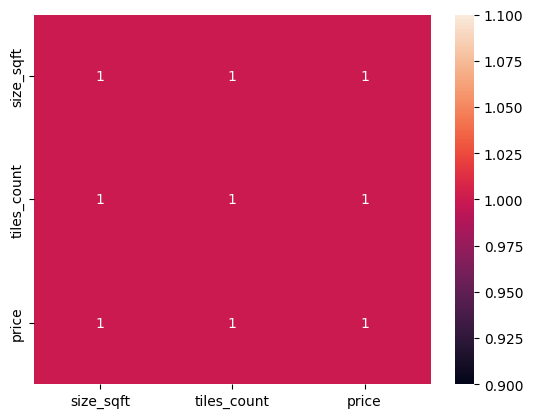

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.heatmap(correlation_matrix,annot=True)
plt.show()


In [ ]:
#Removing highly correlated features
upper=correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape),k=1).astype(bool)
)
to_drop=[column for column in upper.columns if any(upper[column]>0.95)]
print("Highly correlated Featured to Drop:",to_drop)

Highly correlated Featured to Drop: ['tiles_count', 'price']


#**1.3 Chi- Square Test**

In [ ]:
import pandas as pd
X=pd.DataFrame({
    'gender':[0,1,0,1,1],
    'married':[1,1,0,0,1],
    'income':[20000,40000,50000,30000,60000]
})
y=[0,1,1,0,1]
X

,gender,married,income
0,0,1,20000
1,1,1,40000
2,0,0,50000
3,1,0,30000
4,1,1,60000


In [ ]:
#Chi-Square Requires non-negative values
from sklearn.feature_selection import chi2
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X)
selector=SelectKBest(score_func=chi2,k=2)
X_new=selector.fit_transform(X_scaled,y)
selected_features=X.columns[selector.get_support()]
print("Selected Features:",selected_features)

Selected Features: Index(['married', 'income'], dtype='object')


#2. Wrapper Methods

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
print(X.head())
print(X.shape)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0           

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SequentialFeatureSelector

y=data.target
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42
)
model=LogisticRegression(max_iter=50)
model

LogisticRegression(max_iter=50)

#**2.1 Forward Selection**

In [ ]:
sfs=SequentialFeatureSelector(model,
                              n_features_to_select=5,
                              direction='forward')
sfs.fit(X_train,y_train)
selected_features=X.columns[sfs.get_support()]
print("Selected Features:",selected_features)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Selected Features: Index(['mean radius', 'mean texture', 'texture error', 'worst texture',
       'worst perimeter'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#2.2 Backward Elimination

In [ ]:
sfs=SequentialFeatureSelector(model,
                              n_features_to_select=5,
                              direction='backward')
sfs.fit(X_train,y_train)
selected_features=X.columns[sfs.get_support()]
print("Selected Features:",selected_features)


Streaming output truncated to the last 5000 lines.
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/li

Selected Features: Index(['perimeter error', 'area error', 'worst texture', 'worst perimeter',
       'worst compactness'],
      dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

#2.3 Recursive Feature Elimination

In [ ]:
from sklearn.feature_selection import RFE
model=LogisticRegression(max_iter=100)
rfe=RFE(estimator=model,n_features_to_select=5)
rfe.fit(X_train,y_train)
selected_features=X.columns[rfe.support_]
print("Selected Features:",selected_features)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Selected Features: Index(['mean concavity', 'worst compactness', 'worst concavity',
       'worst concave points', 'worst symmetry'],
      dtype='object')
